PCA in Python

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA


In [2]:
iris= load_iris()
X = pd.DataFrame(iris.data, columns=iris.feature_names)
y = pd.Series(iris.target, name = "target")

Andiamo a studiare la disposzione dei dati mediante boxplot

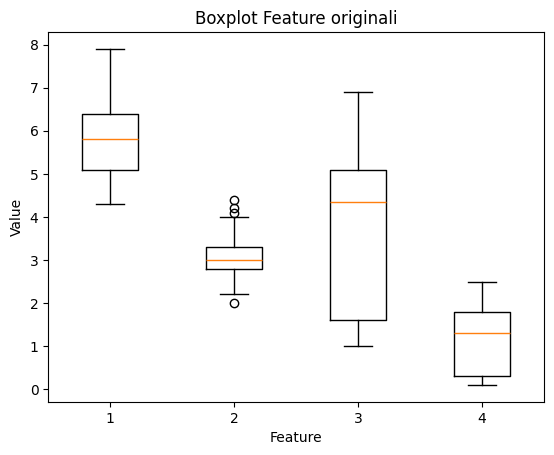

In [ ]:
plt.boxplot(X)
plt.title("Boxplot Feature originali")
plt.xlabel("Feature")
plt.ylabel("Value")
plt.show()

# dal boxplot vediamo che le feature hanno scale diverse, 
# quindi è necessario scalare i dati prima di applicare PCA

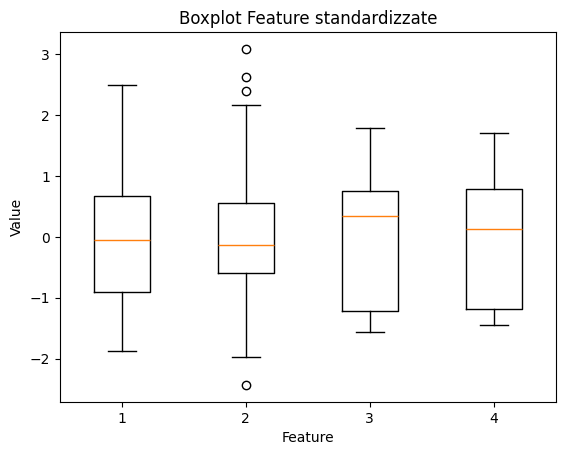

In [4]:
scaler = StandardScaler()
X_std = scaler.fit_transform(X)

plt.boxplot(X_std)
plt.title("Boxplot Feature standardizzate")
plt.xlabel("Feature")
plt.ylabel("Value")
plt.show()

Creazione PCA

In [5]:
pca = PCA()
pca.fit(X_std)

exp_var = pca.explained_variance_ratio_
cum_var = np.cumsum(exp_var)


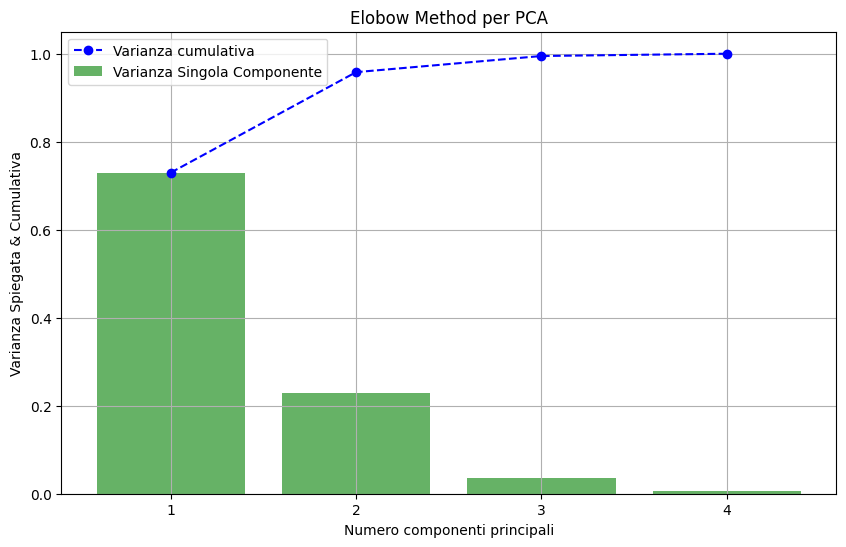

In [7]:
plt.figure(figsize=(10, 6))

plt.plot(range(1, len(cum_var) + 1), cum_var, marker="o", linestyle="--", color = "b", label="Varianza cumulativa")
plt.bar(range(1, len(exp_var) + 1), exp_var, alpha=0.6, color = "g", label="Varianza Singola Componente")

plt.grid(True)
plt.legend()

plt.xticks(range(1, len(exp_var) + 1))
plt.xlabel("Numero componenti principali")
plt.ylabel("Varianza Spiegata & Cumulativa")
plt.title("Elobow Method per PCA")

plt.show()

In [ ]:
# grazie al graffico dell'elbow method possiamo vedere che nel nostro caso il numero di componenti
# ottimali è 2, che spiega più del 90% della varianza totale, ora lo andiamo a calcolare

p = 2

var_retained = cum_var[p-1]
print(f"Varianza totale spiegata con {p} componenti: {var_retained * 100:.2f}%")


Varianza totale spiegata con 2 componenti: 95.81%


In [ ]:
pca_finale = PCA(n_components=p)
X_pca = pca_finale.fit_transform(X_std)

print(f"Dimensione di X_Std: {X_std.shape}")
print(f"Dimensione di X_PCA: {X_pca.shape}")

# con questo vediamo che per le 150 righe del dataset, abbiamo ridotto le feature da 4 a 2, rendendo il tutto più facilmente gestibile


Dimensione di X_Std: (150, 4)
Dimensione di X_PCA: (150, 2)


In [24]:
import time

n_clusters = 3
random_state = 42

kmeans = KMeans(n_clusters=n_clusters, random_state=random_state, n_init="auto")
start_std = time.time()
kmeans.fit(X_std)
end_std = time.time()
time_std = round((end_std - start_std) *1000, 3)

kmeans_pca = KMeans(n_clusters=n_clusters, random_state=random_state, n_init="auto")
start_pca = time.time()
kmeans_pca.fit(X_pca)
end_pca = time.time()
time_pca = round((end_pca - start_pca) *1000, 3)

print(f"KMeans su X_std: {time_std} millisecondi")
print(f"KMeans su X_pca: {time_pca} millisecondi")

KMeans su X_std: 4.276 millisecondi
KMeans su X_pca: 3.104 millisecondi
